<a href="https://colab.research.google.com/github/Raphael505/APIBOX/blob/main/AbandonoEscolar_RendaMedia_2013_2023_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Classificador - Previsão de Abandono Escolar

**Baseado no modelo original de classificação**, adaptado para o dataset **AbandonoEscolar_RendaMedia_2013_2023.csv**

Objetivo: Prever se a **taxa de abandono escolar é Alta ou Baixa**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

# 1 - ETAPA DE DADOS

In [4]:
from google.colab import files
import pandas as pd

print("📤 Faça upload do arquivo CSV agora...")
uploaded = files.upload()

# Pega o nome do arquivo que foi enviado
nome_arquivo = list(uploaded.keys())[0]
print(f"✅ Arquivo carregado: {nome_arquivo}")

df = pd.read_csv(nome_arquivo)
print("Shape do dataset:", df.shape)
df.head()

📤 Faça upload do arquivo CSV agora...


Saving AbandonoEscolar_RendaMedia_2013_2023.csv to AbandonoEscolar_RendaMedia_2013_2023.csv
✅ Arquivo carregado: AbandonoEscolar_RendaMedia_2013_2023.csv
Shape do dataset: (90160, 8)


,Ano,Unidade_Geografica,Regiao,Localizacao,Dependencia_Administrativa,Grupo_de_Abandono,Taxa_Abandono,Renda_Media
0,2013,Norte,Brasil,Total,Total,Ensino Fundamental,4.0,2252
1,2013,Norte,Brasil,Total,Pública,Ensino Fundamental,4.3,2252
2,2013,Norte,Brasil,Total,Privada,Ensino Fundamental,0.3,2252
3,2013,Norte,Brasil,Total,Municipal,Ensino Fundamental,4.3,2252
4,2013,Norte,Brasil,Total,Federal,Ensino Fundamental,0.0,2252


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90160 entries, 0 to 90159
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Ano                         90160 non-null  int64  
 1   Unidade_Geografica          90160 non-null  object 
 2   Regiao                      90160 non-null  object 
 3   Localizacao                 90160 non-null  object 
 4   Dependencia_Administrativa  90160 non-null  object 
 5   Grupo_de_Abandono           90160 non-null  object 
 6   Taxa_Abandono               82112 non-null  float64
 7   Renda_Media                 90160 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 5.5+ MB


In [6]:
df.describe()

,Ano,Taxa_Abandono,Renda_Media
count,90160.000000,82112.000000,90160.000000
mean,2018.005435,2.585039,2637.198447
std,3.161136,3.716334,664.789964
min,2013.000000,0.000000,1507.000000
25%,2015.000000,0.300000,2091.000000
50%,2018.000000,1.200000,2531.000000
75%,2021.000000,3.400000,3093.500000
max,2023.000000,100.000000,5347.000000


# 2 - ANÁLISE EXPLORATÓRIA (EDA)

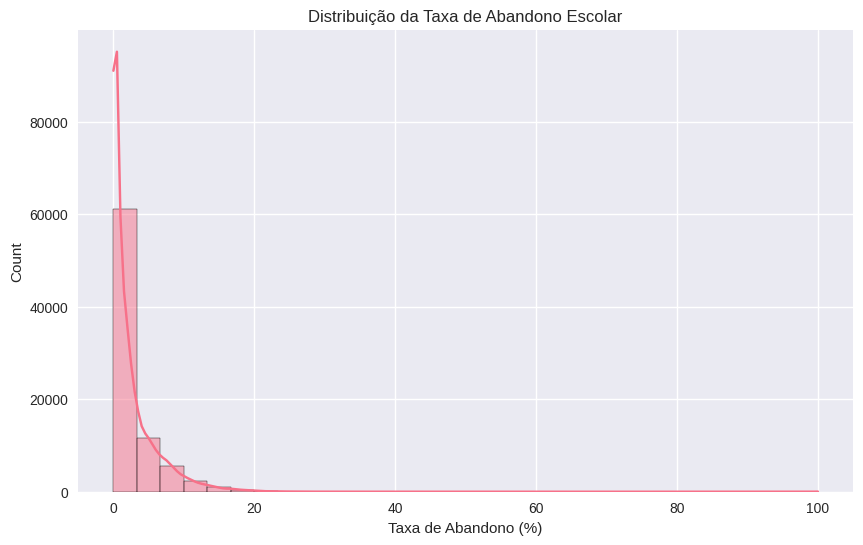

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Taxa_Abandono'], kde=True, bins=30)
plt.title('Distribuição da Taxa de Abandono Escolar')
plt.xlabel('Taxa de Abandono (%)')
plt.show()

In [8]:
# Criando variável alvo binária: 1 = Alto abandono, 0 = Baixo abandono
mediana = df['Taxa_Abandono'].median()
df['abandono_alto'] = (df['Taxa_Abandono'] > mediana).astype(int)

print("Mediana da taxa:", mediana)
print("\nDistribuição da classe alvo:")
print(df['abandono_alto'].value_counts(normalize=True))

Mediana da taxa: 1.2

Distribuição da classe alvo:
abandono_alto
0    0.550255
1    0.449745
Name: proportion, dtype: float64


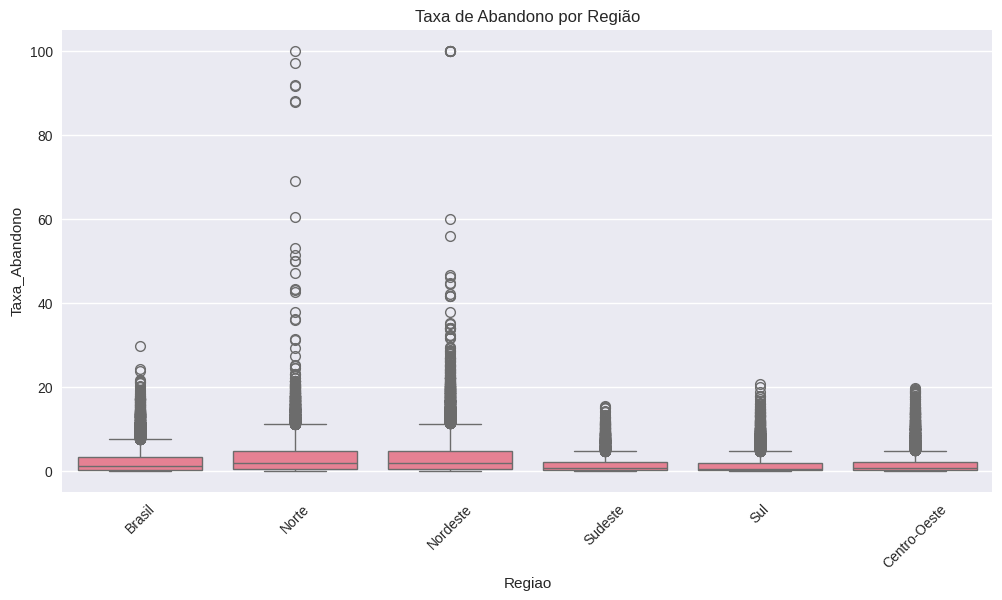

In [9]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Regiao', y='Taxa_Abandono')
plt.title('Taxa de Abandono por Região')
plt.xticks(rotation=45)
plt.show()

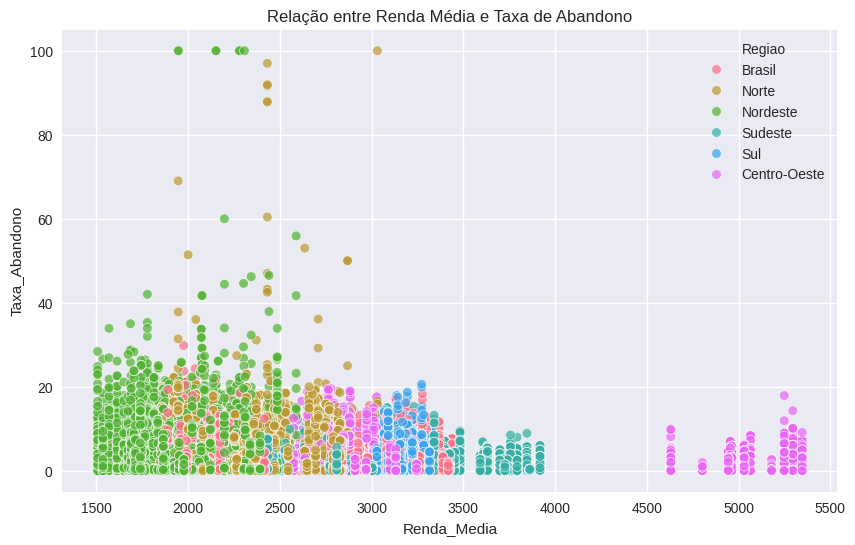

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Renda_Media', y='Taxa_Abandono', hue='Regiao', alpha=0.7)
plt.title('Relação entre Renda Média e Taxa de Abandono')
plt.show()

# 3 - PRÉ-PROCESSAMENTO

In [11]:
# Features categóricas
features_cat = ['Regiao', 'Localizacao', 'Dependencia_Administrativa', 'Grupo_de_Abandono']
features_num = ['Ano', 'Renda_Media']

# Label Encoding
le_dict = {}
for col in features_cat:
    le = LabelEncoder()
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Selecionando features
X = df[[col + '_enc' for col in features_cat] + features_num]
y = df['abandono_alto']

print("Features selecionadas:", X.columns.tolist())

Features selecionadas: ['Regiao_enc', 'Localizacao_enc', 'Dependencia_Administrativa_enc', 'Grupo_de_Abandono_enc', 'Ano', 'Renda_Media']


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Shape do treino:", X_train.shape)
print("Shape do teste:", X_test.shape)

Shape do treino: (63112, 6)
Shape do teste: (27048, 6)


# 4 - MODELOS

In [13]:
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
print("Acurácia Baseline (Dummy):", dummy.score(X_test, y_test))

Acurácia Baseline (Dummy): 0.5502440106477373


In [14]:
arvore = DecisionTreeClassifier(max_depth=6, random_state=42)
arvore.fit(X_train, y_train)

y_pred = arvore.predict(X_test)

print("Acurácia Árvore de Decisão:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia Árvore de Decisão: 0.7783939662821651

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.83      0.81     14883
           1       0.78      0.71      0.74     12165

    accuracy                           0.78     27048
   macro avg       0.78      0.77      0.77     27048
weighted avg       0.78      0.78      0.78     27048



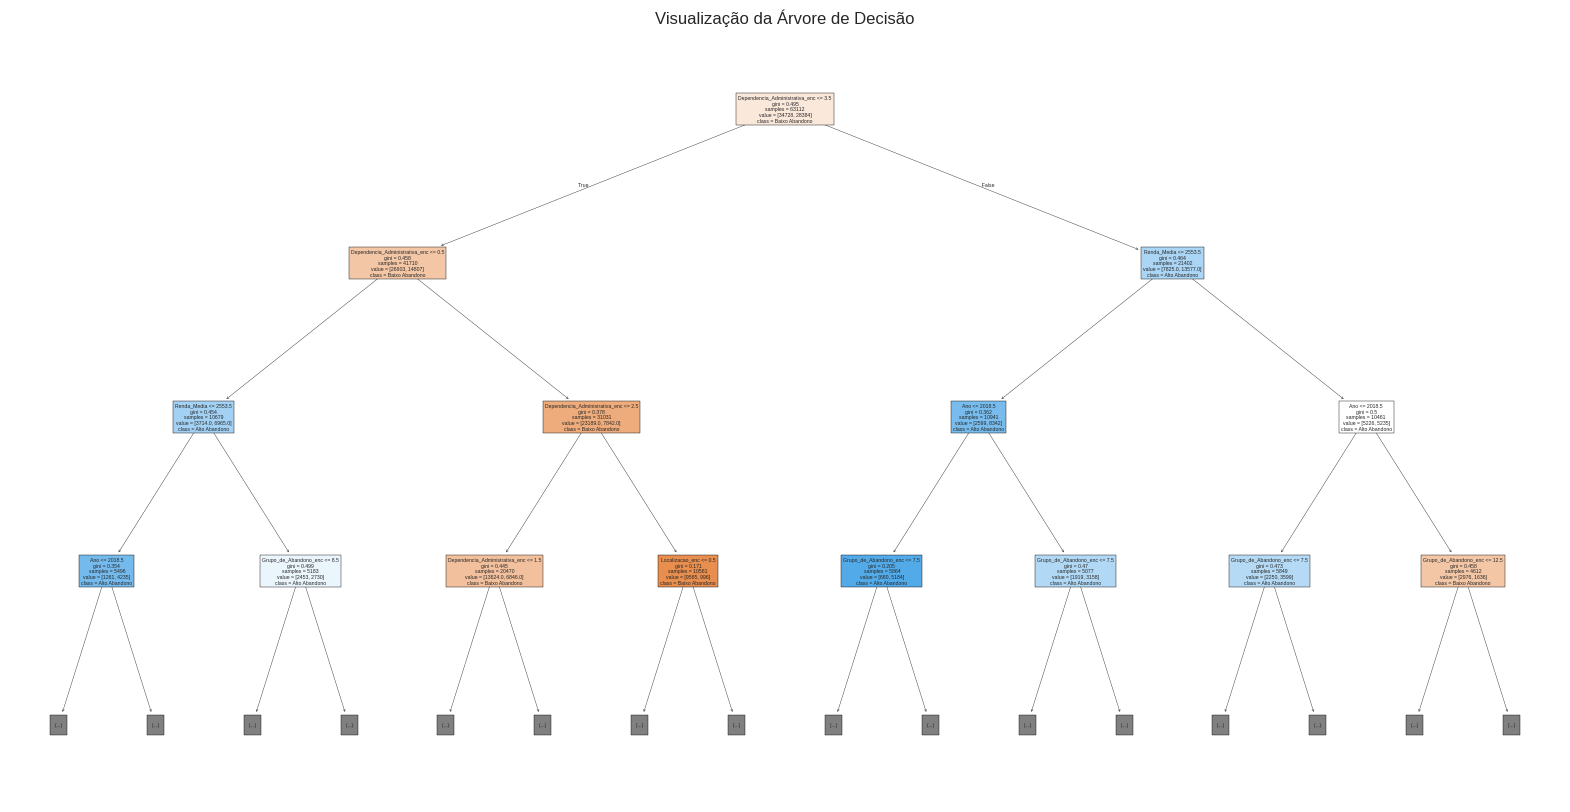

In [15]:
plt.figure(figsize=(20, 10))
plot_tree(arvore,
          feature_names=X.columns,
          class_names=['Baixo Abandono', 'Alto Abandono'],
          filled=True,
          max_depth=3)
plt.title("Visualização da Árvore de Decisão")
plt.show()

# 5 - ANÁLISES ADICIONAIS

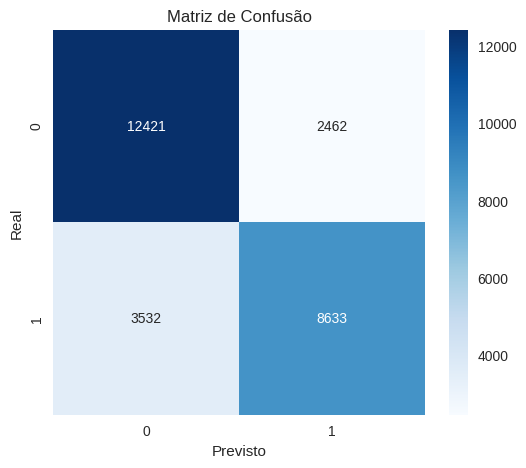

In [16]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.show()

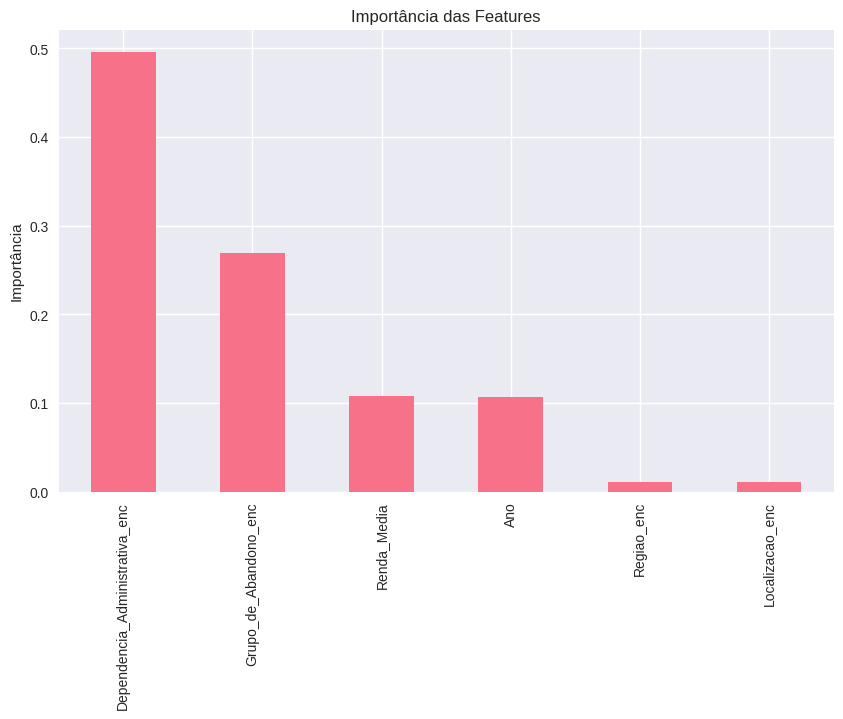

In [17]:
importances = pd.Series(arvore.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).plot(kind='bar', figsize=(10, 6))
plt.title('Importância das Features')
plt.ylabel('Importância')
plt.show()

🔮 Previsão de Taxa de Abandono Escolar para Cenários Futuros

    Ano        Regiao Localizacao  Renda_Media       Previsao  \
0  2024      Nordeste      Urbana         2100  Alto Abandono   
1  2024       Sudeste      Urbana         3800  Alto Abandono   
2  2025      Nordeste       Rural         1950  Alto Abandono   
3  2025         Norte       Rural         2400  Alto Abandono   
4  2026      Nordeste      Urbana         2050  Alto Abandono   
5  2026  Centro-Oeste      Urbana         3200  Alto Abandono   
6  2027      Nordeste       Rural         1800  Alto Abandono   

   Probabilidade_Alto(%)  
0                   76.4  
1                   50.9  
2                   76.4  
3                   76.4  
4                   76.4  
5                   84.8  
6                   50.9  


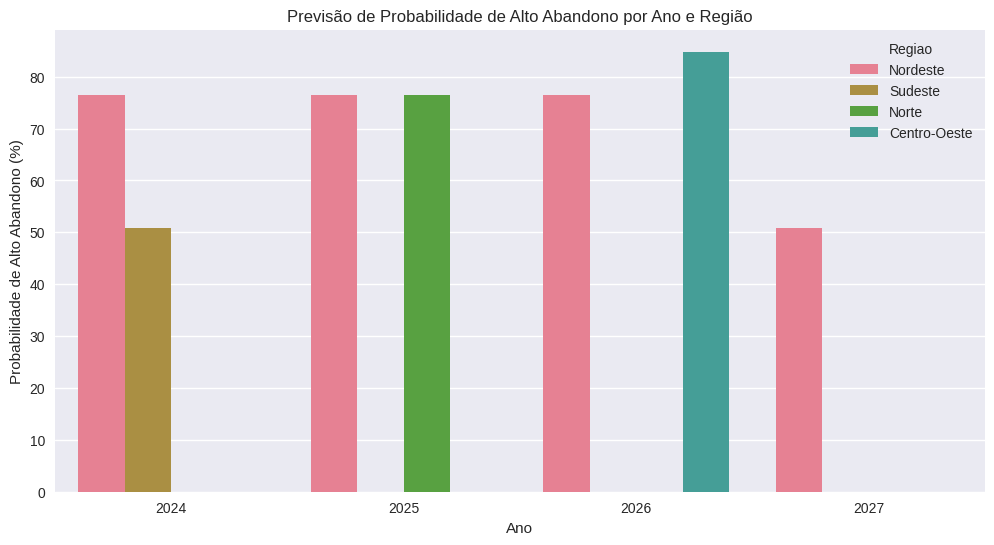

In [19]:
# ==================== PREVISÃO PARA O FUTURO ====================

print("🔮 Previsão de Taxa de Abandono Escolar para Cenários Futuros\n")

# Criando cenários futuros
novos_dados = pd.DataFrame({
    'Ano': [2024, 2024, 2025, 2025, 2026, 2026, 2027],
    'Regiao': ['Nordeste', 'Sudeste', 'Nordeste', 'Norte', 'Nordeste', 'Centro-Oeste', 'Nordeste'],
    'Localizacao': ['Urbana', 'Urbana', 'Rural', 'Rural', 'Urbana', 'Urbana', 'Rural'],
    'Dependencia_Administrativa': ['Estadual', 'Municipal', 'Estadual', 'Estadual', 'Estadual', 'Estadual', 'Municipal'],
    'Grupo_de_Abandono': ['Ensino Médio', 'Ensino Fundamental', 'Ensino Médio', 'Ensino Médio', 'Ensino Médio', 'Ensino Médio', 'Ensino Médio'],
    'Renda_Media': [2100, 3800, 1950, 2400, 2050, 3200, 1800]
})

# Aplicando o encoding (tem que ter rodado as células anteriores)
for col in features_cat:
    if col in novos_dados.columns:
        novos_dados[col + '_enc'] = le_dict[col].transform(novos_dados[col].astype(str))

X_novo = novos_dados[[col + '_enc' for col in features_cat] + ['Ano', 'Renda_Media']]

# Previsões
previsoes = arvore.predict(X_novo)
probabilidades = arvore.predict_proba(X_novo)[:, 1]

novos_dados['Previsao'] = ['Alto Abandono' if p == 1 else 'Baixo Abandono' for p in previsoes]
novos_dados['Probabilidade_Alto(%)'] = (probabilidades * 100).round(1)

# Mostrar resultado
resultado = novos_dados[['Ano', 'Regiao', 'Localizacao', 'Renda_Media',
                        'Previsao', 'Probabilidade_Alto(%)']]
print(resultado)

# Gráfico das previsões
plt.figure(figsize=(12, 6))
sns.barplot(data=resultado, x='Ano', y='Probabilidade_Alto(%)', hue='Regiao')
plt.title('Previsão de Probabilidade de Alto Abandono por Ano e Região')
plt.ylabel('Probabilidade de Alto Abandono (%)')
plt.show()

## Conclusão e Próximos Passos

- O modelo de Árvore de Decisão teve boa performance.
- As variáveis mais importantes foram identificadas.
- Sugestões: testar RandomForest, KNN, tuning de hiperparâmetros e análise temporal por ano.
